# Project.py

In [1]:
import logging
logging.basicConfig(
    level=logging.INFO,
    force=True,
)

import warnings
warnings.filterwarnings(action='ignore')

from polymerist.rdutils import disable_kekulized_drawing
disable_kekulized_drawing()

INFO:rdkit:Enabling RDKit 2023.09.6 jupyter extensions
INFO:numexpr.utils:Note: NumExpr detected 20 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
INFO:numexpr.utils:NumExpr defaulting to 16 threads.


In [2]:
from pathlib import Path
from src.project import (
    PolymerBuildProject,
    mechanism_established,
)

project_path = Path('polyID_test')
# project_path = Path('polyID_production')
project = PolymerBuildProject.get_project(project_path)

[15:14:18] WARNING: not removing hydrogen atom with dummy atom neighbors
INFO:root:Initializing reaction template 1/8 ("polyester")
INFO:root:Initializing test reactants for validation
INFO:root:Initializing reaction template 2/8 ("polyamide")
INFO:root:Initializing test reactants for validation
INFO:root:Initializing reaction template 3/8 ("polyimide")
INFO:root:Initializing test reactants for validation
INFO:root:Initializing reaction template 4/8 ("polycarbonate_phosgene")
INFO:root:Initializing test reactants for validation
INFO:root:Initializing reaction template 5/8 ("polycarbonate_nonphosgene")
INFO:root:Initializing test reactants for validation
INFO:root:Initializing reaction template 6/8 ("polyurethane_isocyanate")
INFO:root:Initializing test reactants for validation
INFO:root:Initializing reaction template 7/8 ("polyurethane_nonisocyanate")
INFO:root:Initializing test reactants for validation
INFO:root:Initializing reaction template 8/8 ("polyvinyl_head_tail")
INFO:root:Init

In [3]:
project.print_status(detailed=True)

Fetching status:   0%|          | 0/832 [00:00<?, ?it/s]

Fetching labels:   0%|          | 0/26 [00:00<?, ?it/s]


Overview: 26 jobs/aggregates, 0 jobs/aggregates with eligible operations.

label                               ratio
----------------------------------  ----------------------------------------------------------
forcefield_is_valid                 |████████████████████████████████████████| 26/26 (100.00%)
chemistry_allowed                   |████████████████████████████████████▉   | 24/26 (92.31%)
copolymer_sequence_kernel_assigned  |███████████████████████████▋            | 18/26 (69.23%)
mechanism_established               |███████████████████████████▋            | 18/26 (69.23%)
autopolymerization_detected         |█████████▏                              | 6/26 (23.08%)
has_banned_atom_types               |███                                     | 2/26 (7.69%)

operation/group
-----------------


Detailed View:

job id                            operation/group    labels
--------------------------------  -----------------  -----------------------------------------------------------

#### Run Jobs

In [ ]:
project.run()

In [ ]:
project.run(
    names=[
        # 'polymerize',
        # 'oligomerize',
        # 'pack_lattice',
        # 'to_interchange',
        'md_export'
    ],
    # jobs=[
    #     project.open_job(id='214e8512b6218c21668ce8c19c6bf359')
    # ]
)

## Inspect jobs

### Checking that aromaticity is being respected

In [4]:
from src.utils.dataIO import read_rxn_mapping_data
from polymerist.rdutils.reactions.reactions import AnnotatedReaction


RXN_DIR : Path = Path('src/reactions')
# RXN_PATHNAME : str = 'rxn_smarts.json'
RXN_PATHNAME : str = 'rxns_polyID.json'

show : bool = not True

# load reactions
rxns : dict[str, AnnotatedReaction] = {}
for rxnname, smarts in read_rxn_mapping_data(RXN_DIR / RXN_PATHNAME).items():
    rxn = AnnotatedReaction.from_smarts(smarts)
    rxns[rxnname] = rxn 
    if show:
        print(rxnname)
        display(rxn)

INFO:root:Reading reaction data from src/reactions/rxns_polyID.json


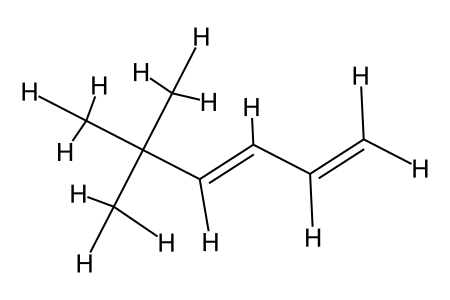

In [15]:
from rdkit import Chem
from rdkit.Chem.rdmolops import SANITIZE_ALL, AROMATICITY_MDL
from polymerist.rdutils.sanitization import sanitize_mol

from polymerist.rdutils.reactions.reactors import PolymerizationReactor
from polymerist.rdutils.reactions.fragment import CutMinimumCostBondsStrategy

build_jobs = [job for job in project if mechanism_established(job)]
job = build_jobs[0]
job = project.open_job(id='455fc6cfdb0fc1e7e8ce8c61ce512567')

monomers = PolymerBuildProject.sanitized_mol_from_smiles(job.sp.smiles_explicit, separate_mols=True)
for m in monomers:
    display(m)

In [17]:
job.doc.is_autopolymerization

True

In [18]:
reactor = PolymerizationReactor(
    rxn_schema=rxns[job.doc.mechanism],
    fragment_strategy=CutMinimumCostBondsStrategy(),
)

fragments = reactor.propagate_pooled(
    monomers=monomers,
    rxn_depth_max=5,
    allow_resampling=job.doc.is_autopolymerization,
    sanitize_ops=PolymerBuildProject.SANITIZE_OPS,
    aromaticity_model=PolymerBuildProject.AROMATICITY_MODEL,
)

INFO:polymerist.rdutils.reactions.reactors:Enumerating fragments formable in 1 reaction step(s) or fewer:
INFO:polymerist.rdutils.reactions.reactors:Found 2 new fragments formable after at least 1 reaction step(s)
INFO:polymerist.rdutils.reactions.reactors:Enumerating fragments formable in 2 reaction step(s) or fewer:
INFO:polymerist.rdutils.reactions.reactors:Found 1 new fragments formable after at least 2 reaction step(s)
INFO:polymerist.rdutils.reactions.reactors:Enumerating fragments formable in 3 reaction step(s) or fewer:
INFO:polymerist.rdutils.reactions.reactors:Found 0 new fragments formable after at least 3 reaction step(s)
INFO:polymerist.rdutils.reactions.reactors:HALTING NORMALLY: No new reaction fragments discovered requiring 3 reaction step(s) or more


0 - C=CC=CC(C)(C)C


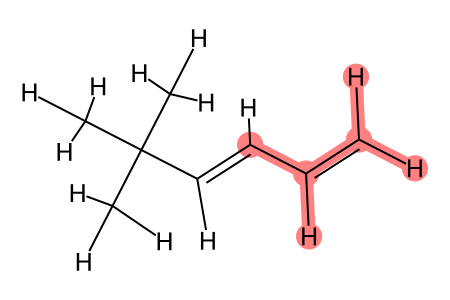

1 - *CCC=CC(C)(C)C


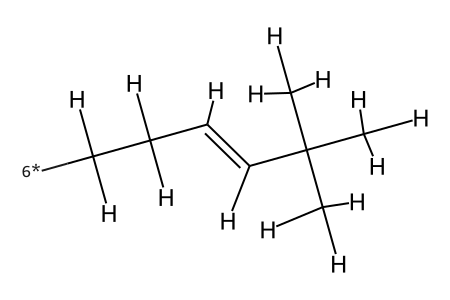

1 - *C(=C)C=CC(C)(C)C


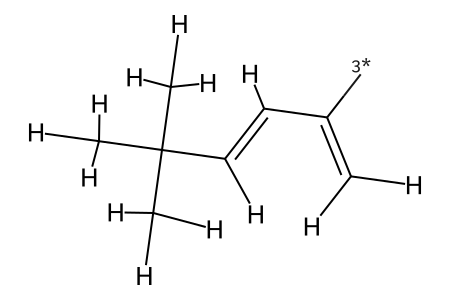

2 - *CC(*)C=CC(C)(C)C


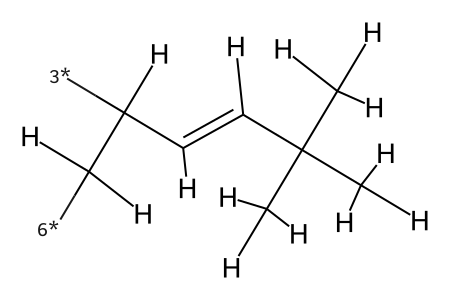

In [19]:
from polymerist.rdutils.bonding.portlib import get_num_linkers

for smiles, frag in fragments.items():
    functionality = get_num_linkers(frag)
    print(f'{functionality} - {smiles}')
    display(frag)

In [12]:
[job.id for job in project if job.doc.get('mechanism') == 'vinyl']

['455fc6cfdb0fc1e7e8ce8c61ce512567',
 'd1f13006e18ae6e11f24893018a92a16',
 '3e3f477a1561ade4fb04595f04f17d26',
 '9c03636d1023c2efe6ad798a5ab427e7',
 '52364a2716f9c01da2e6a583906fa07c',
 'd2e5fb34eeba71e83cc0213f59ab580e']

In [ ]:
job = project.open_job(id='57825dbdb6cab389c8f39ad2db3b4c1d')

In [ ]:
from polymerist.rdutils import set_rdkdraw_size, disable_kekulized_drawing

disable_kekulized_drawing()
set_rdkdraw_size(500, 3/2)

display(mol)

In [ ]:
import pandas as pd

records : list[dict] = []
for job in project:
    op_times = job.doc.get(PolymerBuildProject.OP_TIME_RECORD_NAME)
    if op_times is not None:
        op_times['Job ID'] = job.id
        records.append(op_times)

### Inspect multiple jobs

In [ ]:
from polymerist.genutils.decorators.functional import allow_string_paths

@allow_string_paths
def ls(path : Path) -> None:
    if not path.is_dir():
        raise NotADirectoryError
    for subpath in path.iterdir():
        print(subpath.name)

@allow_string_paths
def cat(path : Path) -> None:
    if not path.is_file():
        raise IsADirectoryError
    
    with path.open('r') as file:
        for line in file.readlines():
            print(line, end='')

In [ ]:
notable_jobs = [
    '214e8512b6218c21668ce8c19c6bf359', # stereochemistry is inverted by file write
    'a4b0a6be41f5786ff9f77f777cda59fa', # long alkane backbone hangs up partitions algorithm
    '41bc5b7d9700c043b78c0b898de4e758', # hangs with NAGL charges
]

In [ ]:
job = project.open_job(id=notable_jobs[-1])
project.get_job_status(job)

In [ ]:
offmol = load_job_oligomer_molecule(job)
offmol

In [ ]:
assign_partial_charges(job)

In [ ]:
cat(job.fn(PolymerBuildProject.LOGFILE_NAME))

In [ ]:
cat(job.fn(PolymerBuildProject.OLIGOMER_SDF))

In [ ]:
ls(job.path)

In [ ]:
with open(job.fn(PolymerBuildProject.LOGFILE_NAME), 'r') as file:
    for line in file.readlines():
        print(line)